In [1]:
"""
Re‑creates your current world + camera demo and opens a matplotlib window.
Run:  python -m examples.demo_world
"""
import numpy as np
import torch

from nerflab import (
    Intrinsics, Camera, Box, Sphere, World, plot_world, CFG, pose_H, make_pose_cases, save_world, load_world, World, Box, Sphere
)

In [2]:
world = load_world("../data/world.json")

In [3]:
# build preset dictionary
cases = make_pose_cases(axis_dist=3)

# pick a view (e.g., diagonal)
H1 = pose_H(cases["+Z"])  
H2 = pose_H(cases["-Z"])  
H3 = pose_H(cases["+X"])  
H4 = pose_H(cases["-X"])  
H5 = pose_H(cases["-Y"])  
H6 = pose_H(cases["+Y"])  
HB = torch.stack((H1, H2, H3, H4, H5, H6))
print(H1.shape)
print(HB.shape)

torch.Size([4, 4])
torch.Size([6, 4, 4])


In [4]:
# --- camera ------------------------------------------------------------------
cam_single   = Camera(H4)

# --- sample rays -------------------------------------------------------------
O_S, D_S = cam_single.get_rays(frame="world")
tS, deltaS, ptsS = cam_single.sample_along_rays(O_S, D_S, rng=torch.manual_seed(0))
print("points shape:", ptsS.shape)

points shape: torch.Size([307200, 20, 3])


In [5]:
# --- camera ------------------------------------------------------------------
cam_batched   = Camera(HB)

# --- sample rays -------------------------------------------------------------
O_B, D_B = cam_batched.get_rays(frame="world")
tB, deltaB, ptsB = cam_batched.sample_along_rays(O_B, D_B, rng=torch.manual_seed(0))
print("points shape:", ptsB.shape)


points shape: torch.Size([6, 307200, 20, 3])


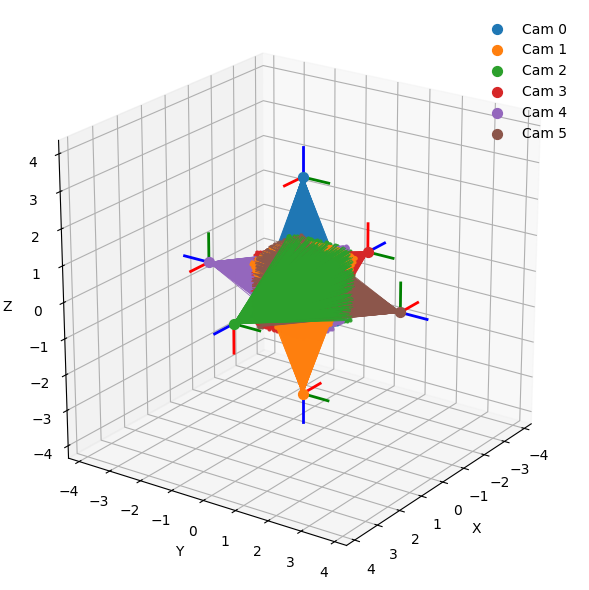

In [6]:
# 1) Single batched camera, draw 1k rays/pose and samples
plot_world(
    world,
    cameras=cam_batched,
    cam_indices="all",
    draw_rays=True, ray_mode="lines", rays_per_pose=1000,
    draw_samples=True, samples_deterministic=True
)



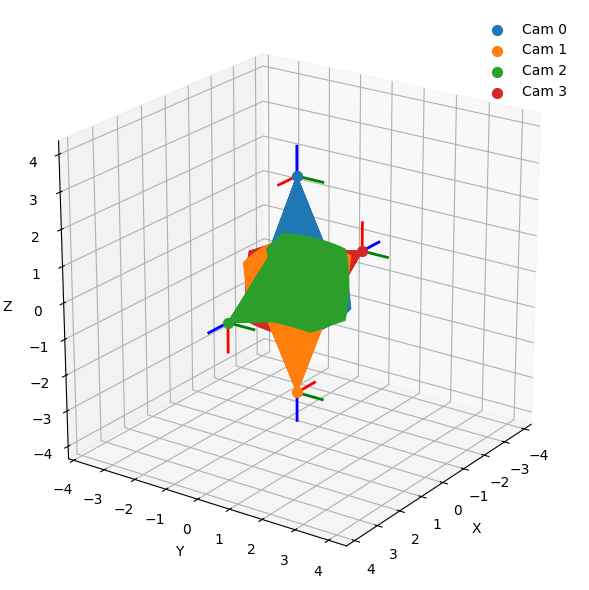

In [7]:

# 2) Two cameras (one batched, one single), show quivers only from first 3 poses
plot_world(
    world,
    cameras=[cam_batched, cam_single],
    cam_indices=[0,1,2],
    draw_rays=True, ray_mode="quiver", ray_step=8
)



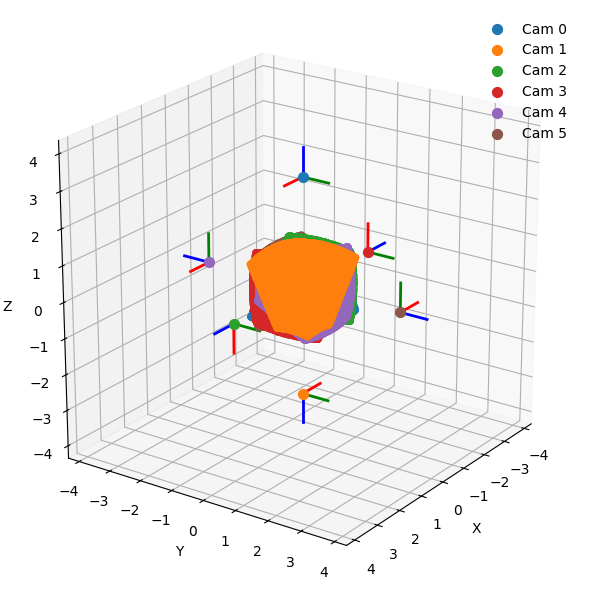

In [8]:
# 3) External point cloud per pose (B,R,N,3), no sampling
plot_world(
    world,
    cameras=cam_batched,
    cam_indices="all",
    external_points=ptsB,
    external_point_size=3.0
)

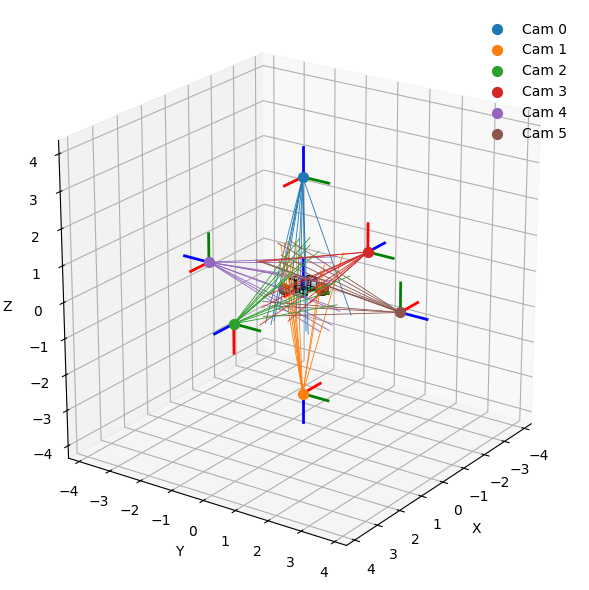

In [9]:
plot_world(
    world,
    cameras=cam_batched,
    cam_indices="all",
    draw_rays=True,
    rays_per_pose=10
)

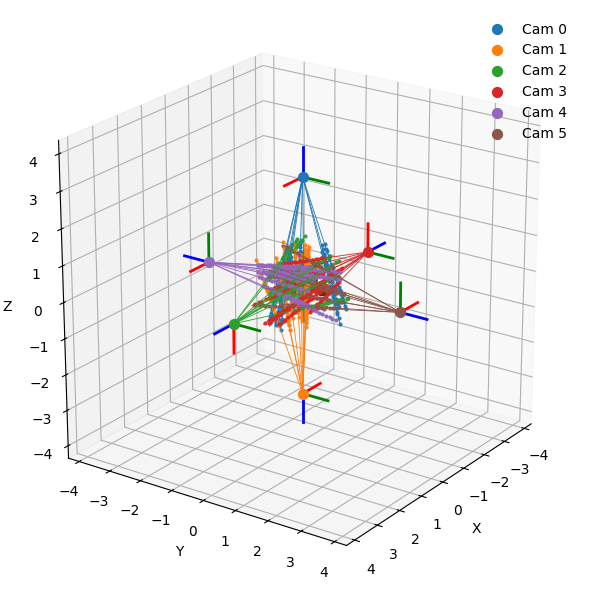

In [10]:
plot_world(
    world,
    cameras=cam_batched,
    cam_indices="all",
    draw_rays=True,
    draw_samples=True,
    rays_per_pose=10
)